# Tutorial 16: Part 2 - Ball thrower

In tutorial 1, we optimized morphology and control. However, the time-dependent behavior of a system also determines possible trajectories, so in the second part we consider morphology and trajectory optimization. We consider an arm that throws a ball, and the task is to find a design that can throw a ball as far as possible.

In [2]:
from thrower.parametric_arm import build, build_to, params, urdfOutPath
import numpy as np
import casadi
import pinocchio as pin
import pinocchio.casadi as cpin
import matplotlib.pyplot as plt
import cma
import time

from robomeshcat import Robot, Scene
from IPython.display import display, IFrame

from thrower.parallel_execution import ParallelEvaluator
from thrower.ocp_utils import frameAcceleration, SX_zeros, framePlacementFunctions, frameVelocityFunctions, frameVelocity

The throwing arm has two actuated links and a gripper that will open at the end of the trajectory. It is shown in the following, and also we select some hyperparameters of the problem: The duration of the trajectory is 2s, with 1000 sampling points. 

In [3]:
scene = Scene(wait_for_open=False)
display(IFrame(scene.vis.url(), width="100%", height=400))

r_baseline = Robot(urdf_path="./thrower/model/parametricArm.urdf")
r = r_baseline
scene.add_robot(r)

# bring to initial position
for i, qi in enumerate([0, np.pi, 0]):
    r[i] = qi

# Hyperparameters
N = 1000
T = 2.0  # final time
dt = T / N
nu = 3
nq = 3
nv = 3

You can open the visualizer by visiting the following URL:
http://127.0.0.1:7000/static/


In this part of the tutorial, we use as well CMA-ES. The difference here is that we formulate a bi-level optimization problem. This means that we have an _outer_ optimization problem that optimizes (in this case) the morphology and an _inner_ optimization problem that solves the trajectory optimization. For each step of the outer optimization problem, the inner optimization problem is solved completely. This method is especially efficient in high-dimensional search spaces. 

<div>
<img src="./media/thrower_codesign.png" width="250"/>
</div>

### Think, Pair, Share
In a sense, the task in part 1 also was a bi-level optimization. Can you tell why?

In the next block, we define a skeleton for the trajectory optimization problem. It initializes the problem with the baseline parameters $l_1 = l_2 = 1m$ and defines some convenience functions for logging and plotting.

In [4]:
class TrajectoryOptimization:
    def __init__(self, desired_position, desired_velocity=None, urdf_out=None, xacro_out=None):
        self.default_params = {
                "link_0": 1.0,
                "link_1": 1.0,
                }
        self.desired_position = desired_position
        self.desired_velocity = desired_velocity
        # Unique paths allow safe parallel use; defaults fall back to shared globals.
        self.urdf_out = urdf_out or urdfOutPath
        self.xacro_out = xacro_out or "/tmp/tmpArm.xml"
       
        self.init_logger()
        
    def init_logger(self):
        self.logger = {
            "params": [],
            "costs": [],
            "xs": [],
            "qs": [],
            "us": [],
            "gripperTrajectory": [],
            "gripperVelocity": []
        }
    
    def get_bounds(self):
        pass

    def fitness(self, params):
        pass

    def log(self, params, cost, xs, qs, us, gripperTrajectory, gripperVelocity):
        self.logger["params"].append(params)
        self.logger["costs"].append(cost)
        self.logger["xs"].append(xs)
        self.logger["qs"].append(qs)
        self.logger["us"].append(us)
        self.logger["gripperTrajectory"].append(gripperTrajectory)
        self.logger["gripperVelocity"].append(gripperVelocity)

    def plot_solution(self, index):
        fig, (ax0, ax1, ax2) = plt.subplots(ncols=3, constrained_layout=True, figsize=(10, 3))

        X = self.logger["xs"][index].T
        U = self.logger["us"][index].T

        time = np.linspace(0, T, N + 1)

        [ax0.plot(time, X[i, :]) for i in range(nq)]
        ax0.legend([f"$q_{i}$" for i in range(nq)])
        ax0.set_xlabel("t [s]")
        ax0.set_title("x")
        ax0.grid(True)

        [ax1.plot(time, X[i, :]) for i in range(nq, nq + nv)]
        ax1.legend([f"$v_{i}$" for i in range(nv)])
        ax1.set_xlabel("t [s]")
        ax1.set_title("v")
        ax1.grid(True)

        [ax2.plot(time[:-1], U[i, :]) for i in range(nu)]
        ax2.legend([f"$u_{i}$" for i in range(nu)])
        ax2.set_xlabel("t [s]")
        ax2.set_title("u")
        ax2.grid(True)

        plt.show()

    def plot_control(self, index):
        fig, (ax0) = plt.subplots(ncols=1, constrained_layout=True)

        time = np.linspace(0, T, N + 1)
        U = self.logger["us"][index]

        [ax0.plot(time[:-1], U[:, i]) for i in range(nu)]
        ax0.legend([f"$u_{i}$" for i in range(nu)])
        ax0.set_xlabel("t [s]")
        ax0.set_title("u")

        plt.show()

    def plot_states(self, index, maxIndex=-1):
        fig, (ax0, ax1) = plt.subplots(ncols=2, constrained_layout=True)

        time = np.linspace(0, T, N + 1)
        time = time[:maxIndex]
        X = self.logger['xs'][index].T[:, :maxIndex]

        [ax0.plot(time, X[i, :]) for i in range(nq)]
        plt.gca().set_prop_cycle(None)
        ax0.legend([f"$q_{i}$" for i in range(nq)])
        ax0.set_xlabel("t [s]")
        ax0.set_title("x")

        [ax1.plot(time, X[i, :]) for i in range(nq, nq + nv)]
        plt.gca().set_prop_cycle(None)
        ax1.legend([f"$v_{i}$" for i in range(nv)])
        ax1.set_xlabel("t [s]")
        ax1.set_title("v")

        plt.show()
    
    def plot_gripper(self, index):
        fig, (ax0, ax1) = plt.subplots(ncols=2, constrained_layout=True)

        time = np.linspace(0, T, N + 1)
        time = time[:]
        gripper_pos = self.logger['gripperTrajectory'][index].T[:, :]
        gripper_vel = self.logger['gripperVelocity'][index].T[:, :]

        [ax0.plot(time, traj) for traj in gripper_pos]
        plt.gca().set_prop_cycle(None)
        ax0.legend(["x", "y", "z"])
        ax0.set_xlabel("t [s]")
        plt.gca().set_prop_cycle(None)
        ax0.hlines(self.desired_position, time[0], time[-1], linestyle="dashed")
        ax0.legend(["desired x", "desired y", "desired z"])
        ax0.set_title("Gripper position")

        [ax1.plot(time, traj) for traj in gripper_vel]
        ax1.legend(["v_x", "v_y", "v_z"])
        ax1.set_xlabel("t [s]")
        plt.gca().set_prop_cycle(None)
        ax1.hlines(self.desired_velocity, time[0], time[-1], linestyle="dashed")
        ax1.legend(["desired v_x", "desired v_y", "desired v_z"])
        ax1.set_title("Gripper velocity")

        plt.show()

Next, the code takes the morphology parameters as an argument and directly modifies the URDF. This changes the leg lengths and the center of mass of the legs. For simplicity, the mass (1.2 kg for first arm, 0.13037 kg for second arm) and inertia of the arms stay the same. In the following, the dynamics are extracted from the URDF using Pinocchio and discretized using Euler-forward integration. 

In [5]:
def dynamics(self, params):
    # Build the model
    l0, l1 = params
    build_to({"link_0" : l0, "link_1" : l1}, self.xacro_out, self.urdf_out)

    # Import the robot
    self.model = model = pin.buildModelFromUrdf(self.urdf_out)
    model.q0 = np.zeros(model.nq)
    model.effortLimit = 0.9 * model.effortLimit
    model.gravity.linear = np.array([0, 0, -9.81])
    self.velocityLimit = 30  # reaching the limits of the actuator

    """
        Preparing for the optimization
    """

    self.cmodel = cmodel = cpin.Model(model)
    self.cdata = cdata = cmodel.createData()

    cq = casadi.SX.sym("q", nq)
    cv = casadi.SX.sym("v", nv)
    ctau = casadi.SX.sym("tau", nu)
    self.cq = cq
    self.cv = cv
    x = casadi.vertcat(cq, cv)
    u = casadi.vertcat(ctau)

    """
        Dynamics
    """
    # Underactuation of the base: the torque is applied only to the last 2 joints
    ctau_joints = ctau

    # Unconstrained case
    # getting the joint acceleration
    a = cpin.aba(cmodel, cdata, cq, cv, ctau_joints)

    # Integrator
    v_next = cv + a * dt
    q_next = cpin.integrate(cmodel, cq, cv * dt)
    x_next = casadi.vertcat(q_next, v_next)

    # state transition function Phi(x, u) -> x+
    self.Phi = casadi.Function("Phi", [x, u], [x_next], ["x", "u"], ["x_next"])

TrajectoryOptimization.dynamics = dynamics 

The next two functions initialize the optimization problem class, and necessary variables and functions.

As for most trajectory optimization problems, we need to add the forward dynamics as constraints. We use direct multiple shooting at all knot points

$$x_{k+1} = x_k + \delta t \cdot f(x_k, u_k)$$

Also, we restrict the z-position of the arm to be above the ground at all times
$$x_z \geq 0.1$$

In [6]:
def prepare_optimization_problem(self):
    """ 
    Prepare the casadi opti optimization problem and variables, and introduce convenience 
    functions for retrieving the gripper and elbow positions/velocities
    """
    # Casadi optimization class
    self.OCP = opti = casadi.Opti()

    # Variables MX type
    self.X = opti.variable(nq+nv, N + 1)
    self.U = opti.variable(nu, N)

    model, cmodel = self.model, self.cmodel
    cdata = self.cdata
    cq, cv = self.cq, self.cv

    # Casadi functions for gripper and elbow frames
    gripperRotation, self.gripperPosition_fn = framePlacementFunctions(
        cmodel, cdata, cq, cv, model.getFrameId("gripper")
    )
    elbowRotation, self.elbowPosition_fn = framePlacementFunctions(
        cmodel, cdata, cq, cv, model.getFrameId("RY_1")
    )
    self.gripperVelocity_fn, _ = frameVelocityFunctions(
        cmodel, cdata, cq, cv, model.getFrameId("gripper")
    )

def dynamics_constraints(self, x0):
    """ Forward dynamics constraints and keeping the arm above the ground """
    opti = self.OCP
    X, U = self.X, self.U

    # Forward dynamics constraints
    for k in range(int(N)):
        opti.subject_to(X[:, k + 1] == self.Phi(X[:, k], U[:, k]))

    # Elbow height constraint
    for i in range(N):
        opti.subject_to(self.elbowPosition_fn(X[:, i])[-1] >= 0.1)  # type: ignore

    # Gripper height constraint
    for i in range(N):
        opti.subject_to(self.gripperPosition_fn(X[:, i])[-1] >= 0.1)  # type: ignore


    # Initial state constraint
    opti.subject_to(X[:, 0] == x0)

    return

TrajectoryOptimization.prepare_optimization_problem = prepare_optimization_problem
TrajectoryOptimization.dynamics_constraints = dynamics_constraints 

The first optimization goal will be to execute a certain throw with the minimal energy.

### Think, Pair, Share

Integrate this objective into a trajectory optimization problem: Think about the objective function and potential constraints. The throw should be executed at a certain height, and the ball should have a given velocity in x- and z-direction. What other constraints do you need to consider?

In [7]:
def traj_opt_setup(self):
    """ Implements the optimization objective and additional constraints """
    opti = self.OCP
    X, U = self.X, self.U

    # Initial state - non-singular, upright position
    q0 = np.array([0, np.pi, 0])
    x0 = np.hstack((q0, np.zeros(nv)))

    # basic forward dynamics constraints
    self.dynamics_constraints(x0)

    obj = 0

    # Lagrange term - penalize inputs and velocities
    for i in range(N):
        obj += 1e-2 * U[:, i].T @ U[:, i] + 1e-3 * X[-nv:, i].T @ X[-nv:, i]

    # Final state cost and task constraints
    obj += 1e3 * casadi.sumsqr(X[:, -1] - x0)

    opti.subject_to(self.gripperPosition_fn(X[:, -1])[2:] == self.desired_position[2:])  # type: ignore
    opti.subject_to(self.gripperVelocity_fn(X[:, -1]) == self.desired_velocity)

    # Initial values for solver
    opti.set_initial(X, np.vstack([x0 for _ in range(N + 1)]).T)

    opti.minimize(obj)

TrajectoryOptimization.traj_opt_setup = traj_opt_setup

Finally, we can solve the optimization problem:

In [ ]:
def solve(self):
    opti = self.OCP
    X = self.X
    U = self.U

    # Options
    opts = {"expand" : True, "print_time":False}
    opts["ipopt"] = {"max_iter": 10000, "tol":1e-2, "print_level":0} # type: ignore

    # Initialization
    opti.solver("ipopt", opts)  # set numerical backend

    try:
        sol = opti.solve_limited()
        print("Problem converged")

    except RuntimeError as e:
        print(e)
        print("Problem NOT converged")

    # Retrieving the solution
    us = np.array(opti.value(U.T))
    xs = np.array(opti.value(X.T))
    qs = xs[:, :nq]
    gripperTrajectory = np.array([opti.value(self.gripperPosition_fn(X[:, i])) for i in range(N + 1)]) # type: ignore
    gripperVelocityTraj = np.array([opti.value(self.gripperVelocity_fn(X[:, i])) for i in range(N + 1)]) # type: ignore

    cost = opti.value(opti.f)
    self.log(self.current_params, cost, xs, qs, us, gripperTrajectory, gripperVelocityTraj)

    return

TrajectoryOptimization.solve = solve

For the outer optimization, we need to provide a fitness value that provides the CMA-ES optimizer the information how well a candidate performs.

### Think, Pair, Share

Complete the fitness function by returning a suitable fitness value. 

In [9]:
def fitness(self, params):
    self.current_params = params
    self.dynamics(params)
    self.prepare_optimization_problem()
    self.traj_opt_setup()
    self.solve()

    inputs = np.array(self.OCP.value(self.U.T))
    fitness_val = np.linalg.norm(inputs)

    return fitness_val

TrajectoryOptimization.fitness = fitness

We can now try to run the trajectory optimization on its own:

In [9]:
optimized_vel = np.array([1, 0, 1])
desired_position = np.array([0, 0, 1.5])

traj_opt = TrajectoryOptimization(desired_position = desired_position, desired_velocity = optimized_vel)
traj_opt.init_logger()

traj_opt.fitness([1.0, 1.0])


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt
******************************************************************************

Problem converged


71.65796994688027

As we see, the problem converges pretty fast! This will will be handy in the next step: Now we implement the outer optimization. Remember, we are aiming at a bilevel optimization of the following form:

<div>
<img src="./media/thrower_codesign.png" width="270"/>
</div>

The inner trajectory optimization is implemented, and `fitness` returns the optimal cost for a given morphology. In the next step, the latter function is passed to CMA-ES the objective function. Besides of the objective, we need to provide an initial guess `x0` of the optimum and an initial covariance guess `sigma0`.

### Think, Pair, Share

Choose a suitable initial guess and covariance guess. Once you have implemented this, you can start the optimization!


In [10]:
start_t = time.time()

x0 = [1.5, 1.0]
sigma0 = 0.5

options = {
    'maxiter': 5,
    'bounds': [[1.0, 1.0], [2.0, 2.0]], 
    'verbose': 1,
}

best_params, _ = cma.fmin2(traj_opt.fitness, x0, sigma0, options)
best_fitness = traj_opt.fitness(best_params) # extract the resulting optimal value and make sure the optimal trajectory is the last in the buffer

print("Best parameters:", best_params)
print("Best fitness:", best_fitness)

params["link_0"], params["link_1"] = best_params
build(params)

print(f"Solution time: {time.time() - start_t} seconds")

/home/raphael/python_venvs/tracks455/lib/python3.12/site-packages/cma/evolution_strategy.py:1541: UserWarning: Sampling standard deviation i=0 (and 1 others) at iteration 0 multiplied by 0.6666666666666666 to stds[0]=0.3333333333333333
  warnings.warn("Sampling standard deviation i={0}{4} at iteration {1}"


(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=743220, Tue May 12 15:58:06 2026)
Problem converged
Problem converged
Problem converged
Problem converged
Problem converged
Problem converged
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1      6 1.015876249489821e+02 1.0e+00 5.77e-01  3e-01  3e-01 0:48.4
Problem converged
Problem converged
Problem converged
Problem converged
Problem converged
Problem converged
    2     12 8.052110939034011e+01 1.5e+00 7.84e-01  3e-01  3e-01 1:36.6
Problem converged
Problem converged
Problem converged
Problem converged
Problem converged
Problem converged
    3     18 7.945729490773719e+01 1.9e+00 7.05e-01  3e-01  3e-01 2:25.2
Problem converged
Problem converged
Problem converged
Problem converged
Problem converged
Problem converged
    4     24 7.663312749609236e+01 1.6e+00 5.52e-01  2e-01  2e-01 3:13.6
Problem converged
Problem converged
Problem converged
Problem converged
Problem converged
Problem converged
    5 

The resulting design and trajectory look like this:

In [14]:
display(IFrame(scene.vis.url(), width="100%", height=400))

r_baseline.visible = False
r.visible = False

r_opt1 = Robot(urdf_path=urdfOutPath)
r = r_opt1
scene.add_robot(r)

In [16]:
start_t = time.time()
subsample = int(0.1/dt)

for idx, q in enumerate(traj_opt.logger['qs'][-1][::subsample]):
    for i, qi in enumerate(q):
        r[i] = qi
    time.sleep(start_t+(idx+1)*0.1 - time.time())    


You can see the inputs and states in the following plots:

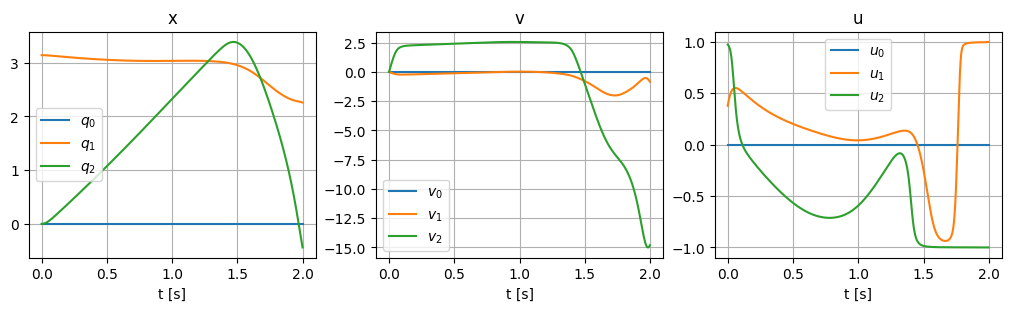

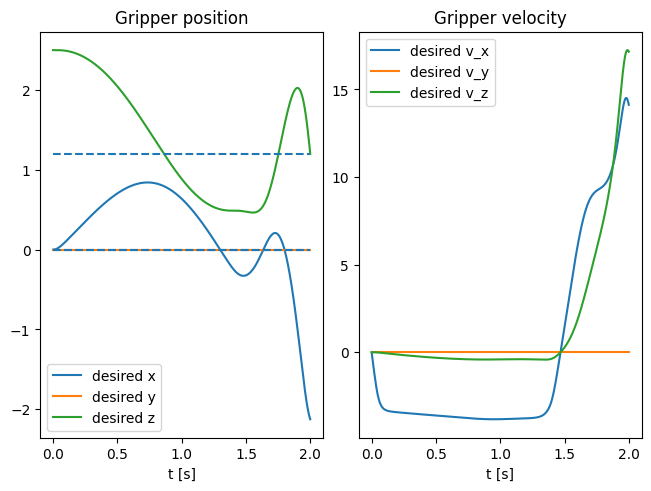

In [17]:
traj_opt.plot_solution(-1)
traj_opt.plot_gripper(-1)

Is it probably clear that depending on our objective, we can get very different behavior. To demonstrate this, we now optimize the arm instead for the maximal throwing distance. To that end, we will provide a desired height (because otherwise longer arms would automatically have an advantage) and try to maximize the distance thrown. 

The trajectory of the ball after leaving the gripper can easily be described by a ballistic curve. Since it is deterministic and only depends on the state at release, we can use this knowledge to formulate our objective: When the ball leaves the gripper at time $N$ at height $h$ with horizontal velocity $v_x$ and vertical velocity $v_z$, the trajectory is:

$$x(t) = v_x \cdot t$$

$$z(t) = h + v_z \cdot t - \frac{1}{2} g t^2$$

The duration $t^*$ of the curve can be calculated by setting $z(t) = 0$

$$t^* = \frac{v_z + \sqrt{v_z^2 + 2gh}}{g}$$

which gives the throwing distance

$$d = v_x \cdot t^* = \frac{v_x}{g}\left(v_z + \sqrt{v_z^2 + 2gh}\right)$$

This is the quantity to _maximize_ over the arm's design/motion parameters, given a fixed release height $h$. Since the CMA-ES library always minimizes the objective, we need to multiply this with $-1$.

### Think, Pair, Share

Implement the necessary objective function in the next cell. To get a well-behaved trajectory, also penalize inputs and velocities slightly.

Also, implement the fitness value for this problem.

In [10]:
def traj_opt_setup_distance(self):
    """Alternative traj_opt_setup that maximizes throwing distance instead of tracking a target velocity."""
    opti = self.OCP
    X, U = self.X, self.U

    # Initial state - non-singular, upright position
    q0 = np.array([0, np.pi, 0])
    x0 = np.hstack((q0, np.zeros(nv)))

    # basic forward dynamics constraints
    self.dynamics_constraints(x0)

    # Cost function
    obj = 0

    # Lagrange term - penalize inputs and velocities
    for i in range(N):
        obj += 1e-4 * U[:, i].T @ U[:, i] + 1e-4 * X[-nv:, i].T @ X[-nv:, i]

    # Maximize throwing distance via projectile formula
    vN = self.gripperVelocity_fn(X[:, -1])
    vx = vN[0]
    vz = vN[2]
    g = 9.81
    distance = vx * (vz + casadi.sqrt(vz**2 + 2*g*self.desired_position[-1])) / g
    obj -= distance # minimize negative distance = maximize distance

    opti.subject_to(vx >= 0)
    opti.subject_to(vz >= 0)

    # Control bounds, system bounds and release height constraint
    for i in range(N):
        opti.subject_to(U[:, i] <= 1)
        opti.subject_to(U[:, i] >= -1)

    maxvel = 15
    for i in range(N):
        for j in range(nq, nq+nv):
            opti.subject_to(-maxvel <= X[j, i])
            opti.subject_to(X[j, i] <= maxvel)

    opti.subject_to(self.gripperPosition_fn(X[:, -1])[2:] == self.desired_position[2:]) 

    opti.set_initial(X, np.vstack([x0 for _ in range(N + 1)]).T)

    opti.minimize(obj)

TrajectoryOptimization.traj_opt_setup = traj_opt_setup_distance

In [ ]:
def fitness_distance(self, params):
    self.current_params = params
    self.dynamics(params)
    self.prepare_optimization_problem()
    self.traj_opt_setup()
    self.solve()

    X = np.array(self.OCP.value(self.X.T))
    vN = self.gripperVelocity_fn(X[-1])
    vx = vN[0]
    vz = vN[2]
    g = 9.81
    distance = vx * (vz + casadi.sqrt(vz**2 + 2*g*self.desired_position[-1])) / g
    fitness_val = -distance # minimize negative distance = maximize distance

    return float(fitness_val)

TrajectoryOptimization.fitness = fitness_distance

Having the objective function and constraints set up, we can solve the problem. First we can test a single trajectory optimization:

In [12]:
desired_position = np.array([0, 0, 1.2]) # only z-coordinate matters

traj_opt = TrajectoryOptimization(desired_position = desired_position)
traj_opt.init_logger()
pppp = [1.5, 1.0]

tt = time.time()
traj_opt.fitness(pppp)
print(time.time() - tt)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt
******************************************************************************

Problem converged
15.481959819793701


As we see, this trajectory optimization takes considerably longer to compute. Depending on the candidate parameters chosen, it even can take more than a minute to compute. Fortunately, CMA-ES is flexible enough that we do not need to evaluate all candidates sequentially, but we can do it in parallel. This is what the `ParallelEvaluator` class is doing for us - otherwise we can call the complete Co-Design optimization as before:

In [13]:
desired_position = np.array([0, 0, 1.2])  # only z-coordinate matters

# ParallelEvaluator takes our trajectory optimization problem and creates multiple instances.
# Each instance lives in its separate thread, so they can be executed in parallel. As a result,
# we do not pass `TrajectoryOptimization.fitness` to the CMA-ES function (single, iterative 
# evaluation), but `parallel_fn` that internally calls `fitness` multiple times in parallel
evaluator = ParallelEvaluator(TrajectoryOptimization, n_workers=10)
parallel_fn = evaluator(desired_position=desired_position)

x0 = [1.5, 1.5]
sigma0 = 0.25
options = {
    'maxiter': 3, # usually, you would use more iterations
    'popsize': 6, # usually, you would also use more evaluations
    'bounds': [[1.0, 1.0], [2.0, 2.0]],
    'verbose': 1,
}

best_params, cmaes_obj = cma.fmin2(parallel_fn.scalar, x0, sigma0, options,
                                parallel_objective=parallel_fn)

print("Best parameters:", best_params)
print("Best fitness:", cmaes_obj.result.fbest)

params["link_0"], params["link_1"] = best_params
build(params)

(5_w,10)-aCMA-ES (mu_w=3.2,w_1=45%) in dimension 2 (seed=677195, Tue May 12 16:05:41 2026)
Problem converged
Problem converged
Problem converged
Problem converged
Problem converged
Problem converged
Problem converged
Problem converged
Problem converged
Problem converged
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     10 -1.607299011433810e+01 1.0e+00 2.58e-01  2e-01  3e-01 3:48.8
Problem converged
Problem converged
Problem converged
Problem converged
Problem converged
Problem converged
Problem converged
Problem converged
Problem converged
Problem converged
    2     20 -4.995064071557599e+01 1.4e+00 3.56e-01  3e-01  3e-01 6:54.1
Problem converged
Problem converged
Problem converged
Problem converged
Problem converged
Problem converged
Problem converged
Problem converged
Problem converged
Problem converged
    3     30 -8.117119442641420e+01 1.5e+00 4.74e-01  3e-01  3e-01 9:42.1
Problem converged
termination on {'maxiter': 3} (Tue May 12 16:15:44 2026)


Again, you can visualize the result:

In [18]:
params["link_0"], params["link_1"] = best_params
build(params)

In [19]:
display(IFrame(scene.vis.url(), width="100%", height=400))

r_baseline.visible = False
r_opt1.visible = False
r.visible = False

r_opt2 = Robot(urdf_path=urdfOutPath)
r = r_opt2
scene.add_robot(r)

In [20]:
start_t = time.time()
subsample = int(0.1/dt)

for idx, q in enumerate(traj_opt.logger['qs'][-1][::subsample]):
    for i, qi in enumerate(q):
        r[i] = qi
    time.sleep(start_t+(idx+1)*0.1 - time.time())   

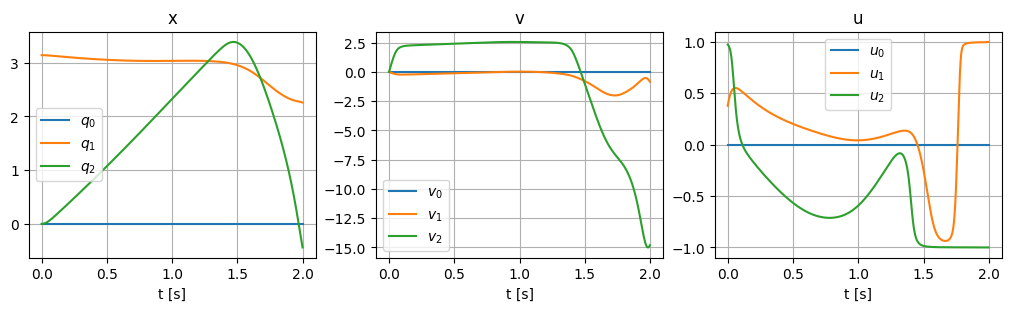

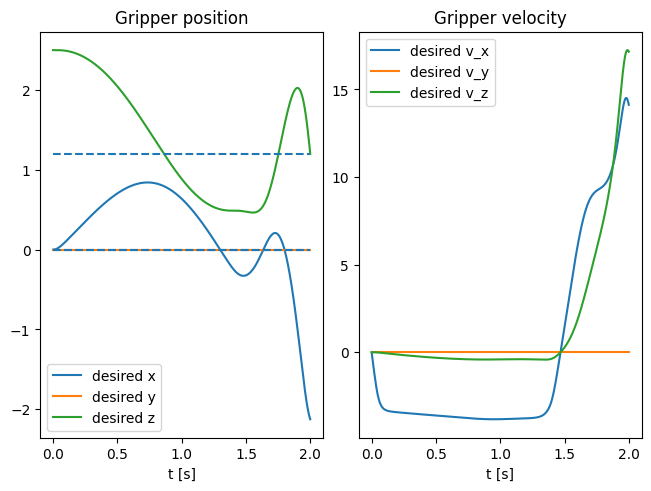

In [22]:
traj_opt.plot_solution(-1)
traj_opt.plot_gripper(-1)

### Think, Pair, Share

What results do you get with the distance-objective instead of the energy objective? Does this reflect your physical intuition of the problem? Why? Why not?

### Think, Pair, Share

What do these results tell you about the relationship between trajectory and morphology?